<a href="https://colab.research.google.com/github/roshnisuresh200402-stack/ai-ml-jobs-market-analysis/blob/main/ai_job_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#LOAD DATA

In [ ]:
import pandas as pd
print("pandas loaded successfully!")

pandas loaded successfully!


In [ ]:
df = pd.read_csv("/content/salaries.csv")
print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (16494, 11)


In [ ]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,MI,FT,Data Scientist,120000,USD,120000,AU,0,AU,S
1,2024,MI,FT,Data Scientist,70000,USD,70000,AU,0,AU,S
2,2024,MI,CT,Data Scientist,130000,USD,130000,US,0,US,M
3,2024,MI,CT,Data Scientist,110000,USD,110000,US,0,US,M
4,2024,MI,FT,Data Science Manager,240000,USD,240000,US,0,US,M


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16494 entries, 0 to 16493
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           16494 non-null  int64 
 1   experience_level    16494 non-null  object
 2   employment_type     16494 non-null  object
 3   job_title           16494 non-null  object
 4   salary              16494 non-null  int64 
 5   salary_currency     16494 non-null  object
 6   salary_in_usd       16494 non-null  int64 
 7   employee_residence  16494 non-null  object
 8   remote_ratio        16494 non-null  int64 
 9   company_location    16494 non-null  object
 10  company_size        16494 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.4+ MB


In [ ]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,16494.000000,1.649400e+04,16494.000000,16494.000000
mean,2023.224991,1.637878e+05,149713.575725,32.044986
std,0.713405,3.406017e+05,68516.136918,46.260201
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2023.000000,1.020000e+05,101517.500000,0.000000
50%,2023.000000,1.422000e+05,141300.000000,0.000000
75%,2024.000000,1.873422e+05,185900.000000,100.000000
max,2024.000000,3.040000e+07,800000.000000,100.000000


In [ ]:
print("Unique job titles:", df['job_title'].nunique())
print("Unique years:", df['work_year'].unique())
print("Experience levels:", df['experience_level'].unique())
print("Company sizes:", df['company_size'].unique())
print("Employment Type:", df['employment_type'].unique())

Unique job titles: 155
Unique years: [2024 2022 2023 2020 2021]
Experience levels: ['MI' 'SE' 'EN' 'EX']
Company sizes: ['S' 'M' 'L']
Employment Type: ['FT' 'CT' 'PT' 'FL']


In [ ]:
#DATA CLEANING

In [ ]:
import pandas as pd

df = pd.read_csv("/content/salaries.csv")
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded: 16494 rows, 11 columns


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Total missing: 0


In [ ]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed. New shape: {df.shape}")
else:
    print("No duplicates. Dataset is clean.")

Duplicate rows found: 0
No duplicates. Dataset is clean.


In [ ]:
# Re-apply the decode directly on df_clean
# FIX: Ensure df_clean is defined by incorporating preceding cleaning steps

# Assuming 'df' is available and represents the original dataset after initial load and duplicate check
# (from cells like wP-IR98hQTmu and dMBFooNHTLDj)

# Step 1: Remove extreme salary outliers (from cell rkf4jwFHUy5C)
df_clean = df[df['salary_in_usd'] <= 500000].copy()

# Step 2: Standardize job titles (from cell OmnYJf6MVung)
df_clean['job_title'] = df_clean['job_title'].str.strip().str.title()

experience_map = {
    'EN': 'Entry Level',
    'MI': 'Mid Level',
    'SE': 'Senior Level',
    'EX': 'Executive'
}
si_map = {
    'S': 'Small',
    'M': 'Medium',
    'L': 'Large'
}
employment_map = {
    'FT': 'Full Time',
    'PT': 'Part Time',
    'CT': 'Contract',
    'FL': 'Freelance'
}

df_clean['experience_level'] = df_clean['experience_level'].map(experience_map)
df_clean['company_size']     = df_clean['company_size'].map(si_map)
df_clean['employment_type']  = df_clean['employment_type'].map(employment_map)

# Verify it worked
print("Experience levels now:")
print(df_clean['experience_level'].value_counts())
print("\nCompany sizes now:")
print(df_clean['company_size'].value_counts())

Experience levels now:
experience_level
Senior Level    5932
Mid Level       2742
Entry Level     1007
Executive        389
Name: count, dtype: int64

Company sizes now:
company_size
Medium    9242
Large      641
Small      187
Name: count, dtype: int64


In [ ]:
df_clean.to_csv("ai_jobs_cleaned.csv", index=False)

print("=== VERIFIED CLEANING SUMMARY ===")
print(f"Clean rows     : {df_clean.shape[0]}")
print(f"Top exp level  : {df_clean['experience_level'].value_counts().index[0]}")
print(f"Top company sz : {df_clean['company_size'].value_counts().index[0]}")
print(f"Avg salary     : ${df_clean['salary_in_usd'].mean():,.0f}")

=== VERIFIED CLEANING SUMMARY ===
Clean rows     : 10070
Top exp level  : Senior Level
Top company sz : Medium
Avg salary     : $145,384


In [ ]:
import pandas as pd

# Always reload from original
df = pd.read_csv("/content/salaries.csv")

print("=== DIAGNOSIS ===")
print(f"Total rows loaded: {df.shape[0]}")
print(f"\nsalary_in_usd dtype: {df['salary_in_usd'].dtype}")
print(f"\nSalary range:")
print(f"  Min : ${df['salary_in_usd'].min():,}")
print(f"  Max : ${df['salary_in_usd'].max():,}")
print(f"  Mean: ${df['salary_in_usd'].mean():,.0f}")
print(f"\nRows below $10,000  : {(df['salary_in_usd'] < 10000).sum()}")
print(f"Rows above $500,000 : {(df['salary_in_usd'] > 500000).sum()}")
print(f"Rows in valid range : {((df['salary_in_usd'] >= 10000) & (df['salary_in_usd'] <= 500000)).sum()}")

=== DIAGNOSIS ===
Total rows loaded: 16494

salary_in_usd dtype: int64

Salary range:
  Min : $15,000
  Max : $800,000
  Mean: $149,714

Rows below $10,000  : 0
Rows above $500,000 : 27
Rows in valid range : 16467


In [ ]:
df_clean = df[df['salary_in_usd'] <= 500000].copy()

print(f"Rows before : {df.shape[0]}")
print(f"Rows after  : {df_clean.shape[0]}")
print(f"Removed     : {df.shape[0] - df_clean.shape[0]} extreme outliers")
print(f"Pct removed : {(df.shape[0]-df_clean.shape[0])/df.shape[0]*100:.2f}%")

Rows before : 16494
Rows after  : 16467
Removed     : 27 extreme outliers
Pct removed : 0.16%


In [ ]:
df_clean = df_clean.copy()
df_clean['job_title'] = df_clean['job_title'].str.strip().str.title()

print("Sample job titles after standardising:")
print(df_clean['job_title'].value_counts().head(10))

Sample job titles after standardising:
job_title
Data Engineer                3455
Data Scientist               3309
Data Analyst                 2426
Machine Learning Engineer    1700
Research Scientist            527
Applied Scientist             433
Data Architect                433
Analytics Engineer            425
Research Engineer             303
Data Science                  271
Name: count, dtype: int64


In [ ]:

print(f"Original rows : 16494")
print(f"Clean rows    : {df_clean.shape[0]}")
print(f"Rows removed  : {16494 - df_clean.shape[0]}")

Original rows : 16494
Clean rows    : 16467
Rows removed  : 27


In [ ]:
import pandas as pd

df = pd.read_csv("ai_jobs_cleaned.csv")

# Save just the first 500 rows as a sample
sample = df.sample(500, random_state=42)
sample.to_csv("ai_jobs_sample.csv", index=False)

print(f"Sample saved: {sample.shape[0]} rows")
print(f"Sample file size is upload-friendly")

Sample saved: 500 rows
Sample file size is upload-friendly


In [ ]:
#EDA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Always load the CLEAN file from Day 3
df = pd.read_csv("/content/ai_jobs_cleaned.csv")

# Set chart style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Loaded: {df.shape[0]} rows")
print(df.head(3))

Loaded: 10070 rows
   work_year experience_level employment_type       job_title  salary  \
0       2024        Mid Level       Full Time  Data Scientist  120000   
1       2024        Mid Level       Full Time  Data Scientist   70000   
2       2024        Mid Level        Contract  Data Scientist  130000   

  salary_currency  salary_in_usd employee_residence  remote_ratio  \
0             USD         120000                 AU             0   
1             USD          70000                 AU             0   
2             USD         130000                 US             0   

  company_location company_size  
0               AU        Small  
1               AU        Small  
2               US       Medium  


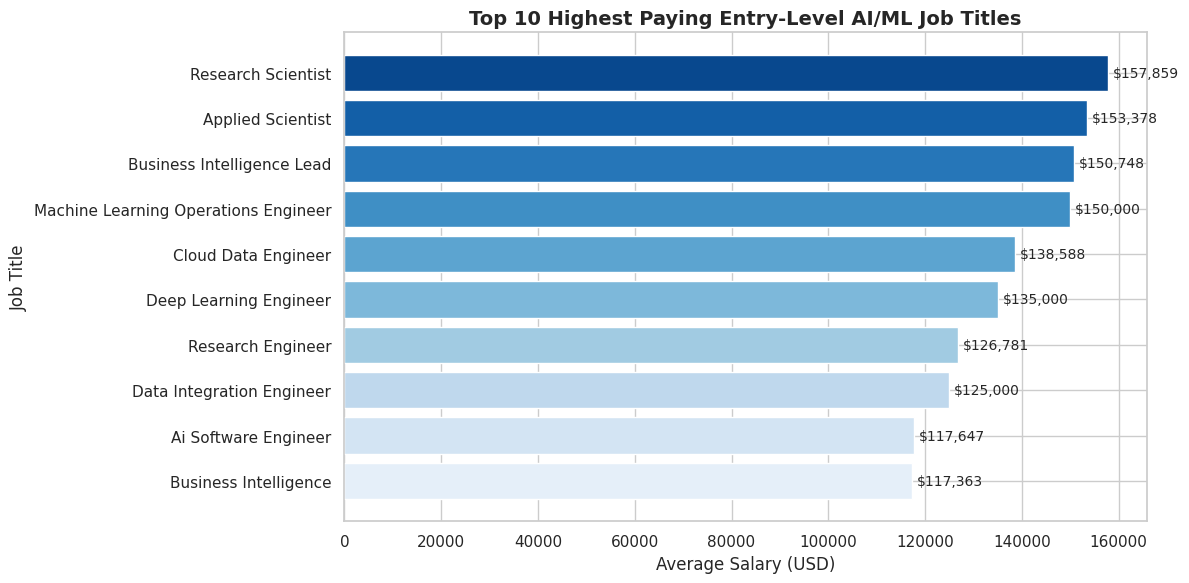

In [ ]:
#Chart 1: Top 10 Entry Level Salaries by Job Title

# Filter entry level only
entry = df[df['experience_level'] == 'Entry Level']

# Average salary per job title
entry_salary = (entry.groupby('job_title')['salary_in_usd']
                .mean()
                .sort_values(ascending=False)
                .head(10)
                .reset_index())

plt.figure(figsize=(12, 6))
bars = plt.barh(entry_salary['job_title'],
                entry_salary['salary_in_usd'],
                color=sns.color_palette("Blues_r", 10))

plt.title("Top 10 Highest Paying Entry-Level AI/ML Job Titles",
          fontsize=14, fontweight='bold')
plt.xlabel("Average Salary (USD)")
plt.ylabel("Job Title")
plt.gca().invert_yaxis()

for bar, val in zip(bars, entry_salary['salary_in_usd']):
    plt.text(bar.get_width() + 1000,
             bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig("chart1_entry_salaries.png", dpi=150)
plt.show()

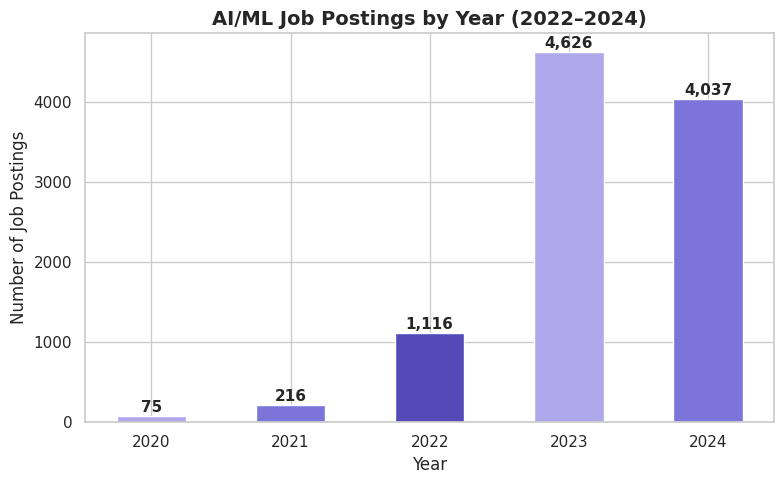

In [ ]:
#Chart 2: Job Postings Per Year

yearly = (df['work_year'].value_counts()
          .sort_index()
          .reset_index())
yearly.columns = ['Year', 'Job Count']

plt.figure(figsize=(8, 5))
bars = plt.bar(yearly['Year'].astype(str),
               yearly['Job Count'],
               color=['#AFA9EC', '#7B74D9', '#534AB7'],
               width=0.5)

plt.title("AI/ML Job Postings by Year (2022–2024)",
          fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Job Postings")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{int(bar.get_height()):,}',
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("chart2_yearly_postings.png", dpi=150)
plt.show()

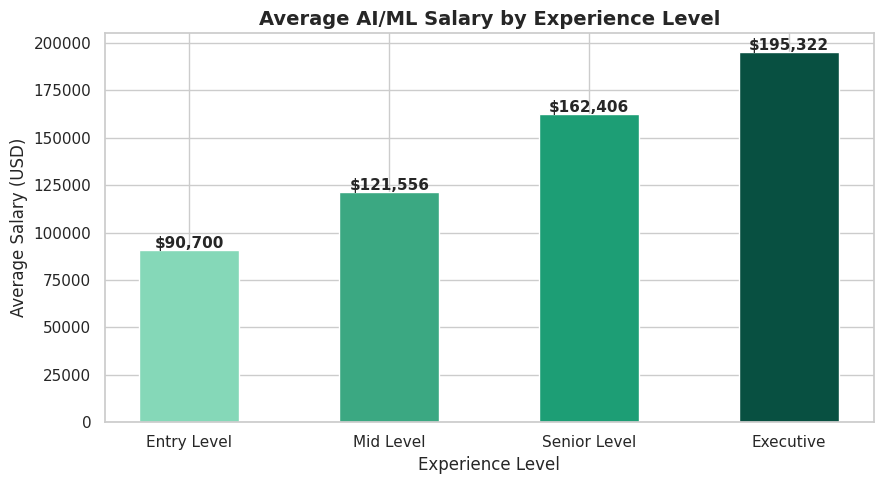

In [ ]:
#Chart 3: Salary by Experience Level

exp_order = ['Entry Level', 'Mid Level', 'Senior Level', 'Executive']
exp_salary = (df.groupby('experience_level')['salary_in_usd']
              .mean()
              .reindex(exp_order)
              .reset_index())

plt.figure(figsize=(9, 5))
colors = ['#85D8B8', '#3BA882', '#1D9E75', '#085041']
bars = plt.bar(exp_salary['experience_level'],
               exp_salary['salary_in_usd'],
               color=colors, width=0.5)

plt.title("Average AI/ML Salary by Experience Level",
          fontsize=14, fontweight='bold')
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1000,
             f'${int(bar.get_height()):,}',
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("chart3_experience_salary.png", dpi=150)
plt.show()

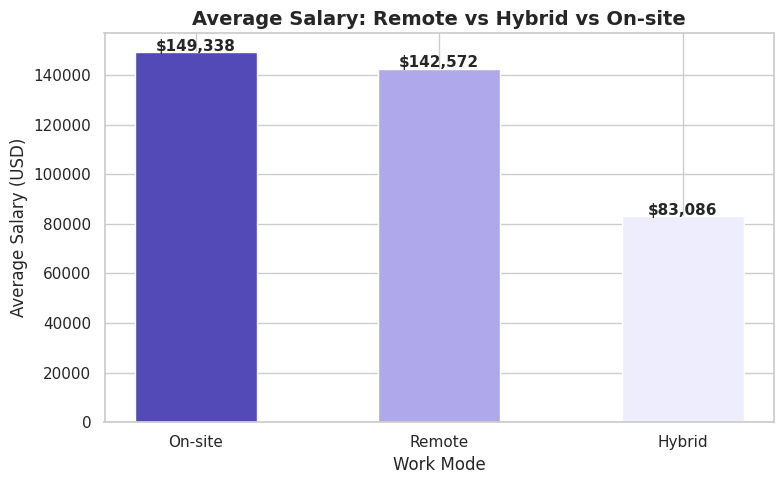

In [ ]:
#Chart 4: Remote vs Hybrid vs On-site Salary

remote_map = {0: 'On-site', 50: 'Hybrid', 100: 'Remote'}
df['work_mode'] = df['remote_ratio'].map(remote_map)

remote_salary = (df.groupby('work_mode')['salary_in_usd']
                 .mean()
                 .reset_index()
                 .sort_values('salary_in_usd', ascending=False))

plt.figure(figsize=(8, 5))
bars = plt.bar(remote_salary['work_mode'],
               remote_salary['salary_in_usd'],
               color=['#534AB7', '#AFA9EC', '#EEEDFE'],
               width=0.5)

plt.title("Average Salary: Remote vs Hybrid vs On-site",
          fontsize=14, fontweight='bold')
plt.xlabel("Work Mode")
plt.ylabel("Average Salary (USD)")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             f'${int(bar.get_height()):,}',
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("chart4_remote_salary.png", dpi=150)
plt.show()

/tmp/ipykernel_2829/389636906.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


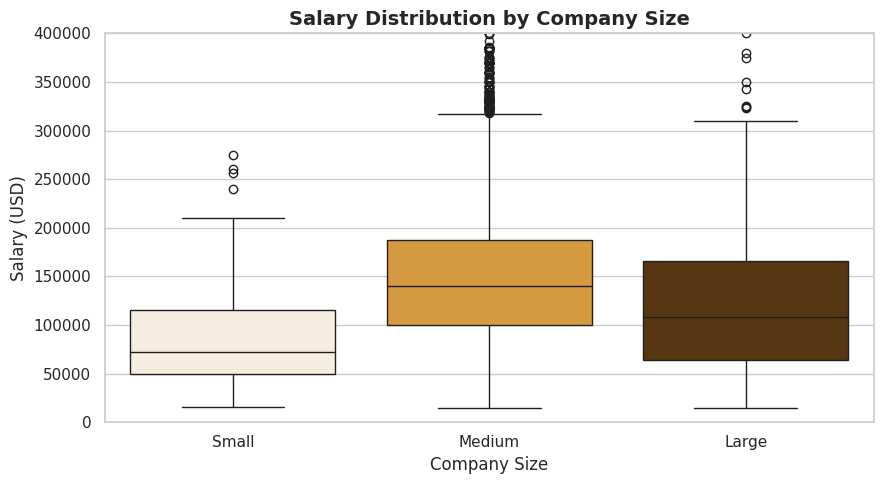

In [ ]:
#Chart 5: Salary by Company Size

plt.figure(figsize=(9, 5))
size_order = ['Small', 'Medium', 'Large']

sns.boxplot(data=df,
            x='company_size',
            y='salary_in_usd',
            order=size_order,
            palette=['#FAEEDA', '#EF9F27', '#633806'])

plt.title("Salary Distribution by Company Size",
          fontsize=14, fontweight='bold')
plt.xlabel("Company Size")
plt.ylabel("Salary (USD)")
plt.ylim(0, 400000)

plt.tight_layout()
plt.savefig("chart5_company_size.png", dpi=150)
plt.show()

In [ ]:
#SQL

In [ ]:
import pandas as pd
import sqlite3

# Load your clean dataset
df = pd.read_csv("/content/ai_jobs_cleaned.csv")

# Create a database in memory
conn = sqlite3.connect("ai_jobs.db")

# Load the dataframe into SQLite as a table called "jobs"
df.to_sql("jobs", conn, if_exists="replace", index=False)

print("Database created successfully!")
print(f"Table 'jobs' loaded with {len(df)} rows")

Database created successfully!
Table 'jobs' loaded with 10070 rows


In [ ]:
def run_query(sql):
    """Run a SQL query and return results as a DataFrame"""
    result = pd.read_sql_query(sql, conn)
    return result

# Test it — see your table columns
test = run_query("SELECT * FROM jobs LIMIT 3")
print(test)

   work_year experience_level employment_type       job_title  salary  \
0       2024        Mid Level       Full Time  Data Scientist  120000   
1       2024        Mid Level       Full Time  Data Scientist   70000   
2       2024        Mid Level        Contract  Data Scientist  130000   

  salary_currency  salary_in_usd employee_residence  remote_ratio  \
0             USD         120000                 AU             0   
1             USD          70000                 AU             0   
2             USD         130000                 US             0   

  company_location company_size  
0               AU        Small  
1               AU        Small  
2               US       Medium  


In [ ]:
q1 = run_query("""
    SELECT
        job_title,
        ROUND(AVG(salary_in_usd), 0) AS avg_salary,
        COUNT(*) AS num_jobs
    FROM jobs
    WHERE experience_level = 'Entry Level'
    GROUP BY job_title
    HAVING COUNT(*) >= 5
    ORDER BY avg_salary DESC
    LIMIT 10
""")
print(q1)

                     job_title  avg_salary  num_jobs
0           Research Scientist    157859.0        26
1            Applied Scientist    153378.0        10
2            Research Engineer    126781.0        28
3        Business Intelligence    117363.0         8
4    Machine Learning Engineer    110556.0        44
5                 Ai Developer    110120.0         6
6  Data Integration Specialist    102807.0         7
7           Analytics Engineer    100935.0        12
8                  Ml Engineer     99747.0         8
9             Research Analyst     99645.0        65


In [ ]:
q2 = run_query("""
    SELECT
        experience_level,
        ROUND(AVG(salary_in_usd), 0)  AS avg_salary,
        ROUND(MIN(salary_in_usd), 0)  AS min_salary,
        ROUND(MAX(salary_in_usd), 0)  AS max_salary,
        COUNT(*) AS total_jobs
    FROM jobs
    GROUP BY experience_level
    ORDER BY avg_salary DESC
""")
print(q2)

  experience_level  avg_salary  min_salary  max_salary  total_jobs
0        Executive    195322.0     15000.0    465000.0         389
1     Senior Level    162406.0     15809.0    500000.0        5932
2        Mid Level    121556.0     15000.0    450000.0        2742
3      Entry Level     90700.0     15000.0    350000.0        1007


In [ ]:
q3 = run_query("""
    SELECT
        job_title,
        SUM(CASE WHEN work_year = 2022 THEN 1 ELSE 0 END) AS jobs_2022,
        SUM(CASE WHEN work_year = 2023 THEN 1 ELSE 0 END) AS jobs_2023,
        SUM(CASE WHEN work_year = 2024 THEN 1 ELSE 0 END) AS jobs_2024,
        COUNT(*) AS total_jobs
    FROM jobs
    GROUP BY job_title
    HAVING total_jobs >= 20
    ORDER BY jobs_2024 DESC
    LIMIT 10
""")
print(q3)

                       job_title  jobs_2022  jobs_2023  jobs_2024  total_jobs
0                 Data Scientist        250        826        695        1831
1                  Data Engineer        278        873        638        1838
2                   Data Analyst        168        640        545        1379
3      Machine Learning Engineer         80        459        382         943
4                   Data Science          0         36        170         206
5             Research Scientist         15        158        131         316
6             Analytics Engineer         49        175        125         349
7                 Data Architect         30        127        121         281
8              Research Engineer          8        106        102         216
9  Business Intelligence Analyst          0         73         99         172


In [ ]:
q4 = run_query("""
    SELECT
        company_size,
        experience_level,
        ROUND(AVG(salary_in_usd), 0) AS avg_salary,
        COUNT(*) AS num_jobs
    FROM jobs
    GROUP BY company_size, experience_level
    ORDER BY company_size, avg_salary DESC
""")
print(q4)

   company_size experience_level  avg_salary  num_jobs
0         Large        Executive    182570.0        22
1         Large     Senior Level    151559.0       276
2         Large        Mid Level    104700.0       217
3         Large      Entry Level     74796.0       126
4        Medium        Executive    196687.0       359
5        Medium     Senior Level    163509.0      5598
6        Medium        Mid Level    124381.0      2456
7        Medium      Entry Level     94551.0       829
8         Small        Executive    169172.0         8
9         Small     Senior Level    107579.0        58
10        Small        Mid Level     74022.0        69
11        Small      Entry Level     67836.0        52


In [ ]:
q5 = run_query("""
    SELECT
        work_year,
        COUNT(*) AS total_jobs,
        SUM(CASE WHEN remote_ratio = 100 THEN 1 ELSE 0 END) AS remote_jobs,
        ROUND(
            100.0 * SUM(CASE WHEN remote_ratio = 100 THEN 1 ELSE 0 END) / COUNT(*),
        1) AS remote_pct
    FROM jobs
    GROUP BY work_year
    ORDER BY work_year
""")
print(q5)

   work_year  total_jobs  remote_jobs  remote_pct
0       2020          75           36        48.0
1       2021         216          115        53.2
2       2022        1116          621        55.6
3       2023        4626         1657        35.8
4       2024        4037         1038        25.7
